# Olist Brazilian E-Commerce — Data Analyst Case Study
**Habuild | Data Analyst Role**

This notebook covers:
1. Data loading & merging
2. Exploratory Data Analysis (EDA)
3. Hypothesis testing
4. Actionables & Further Exploration

In [2]:
# ── CELL 1: Install & Imports ──────────────────────────────────────────────
# pip install pandas numpy matplotlib seaborn scipy statsmodels plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Plot defaults
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (10, 5)})

print('All imports successful.')

All imports successful.


In [3]:
# ── CELL 2: Load Data ──────────────────────────────────────────────────────
# Update DATA_PATH to wherever you extracted the Kaggle dataset
DATA_PATH = 'C:/Users/HP/Desktop/project/data/'   # <-- change this

customers  = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
orders     = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
items      = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
products   = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
reviews    = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')
payments   = pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
sellers    = pd.read_csv(DATA_PATH + 'olist_sellers_dataset.csv')
geo        = pd.read_csv(DATA_PATH + 'olist_geolocation_dataset.csv')
cat_trans  = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')

print('Shapes:')
for name, df in [('customers',customers),('orders',orders),('items',items),
                  ('products',products),('reviews',reviews),('payments',payments),
                  ('sellers',sellers),('geo',geo),('cat_trans',cat_trans)]:
    print(f'  {name:15s}: {df.shape}')

Shapes:
  customers      : (99441, 5)
  orders         : (99441, 8)
  items          : (112650, 7)
  products       : (32951, 9)
  reviews        : (99224, 7)
  payments       : (103886, 5)
  sellers        : (3095, 4)
  geo            : (1000163, 5)
  cat_trans      : (71, 2)


In [4]:
# ── CELL 3: Parse Dates ────────────────────────────────────────────────────
date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

reviews['review_creation_date']      = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp']   = pd.to_datetime(reviews['review_answer_timestamp'])

print('Dates parsed.')

Dates parsed.


In [5]:
# ── CELL 4: Build Master Table ─────────────────────────────────────────────
# Aggregate payments per order
pay_agg = payments.groupby('order_id').agg(
    total_payment=('payment_value','sum'),
    payment_installments=('payment_installments','max'),
    payment_type=('payment_type', lambda x: x.mode()[0])
).reset_index()

# Aggregate items per order
items_agg = items.groupby('order_id').agg(
    n_items=('order_item_id','count'),
    total_price=('price','sum'),
    total_freight=('freight_value','sum')
).reset_index()

# Translate categories
products = products.merge(cat_trans, on='product_category_name', how='left')

# Most common category per order
items_cat = items.merge(products[['product_id','product_category_name_english']], on='product_id', how='left')
cat_per_order = items_cat.groupby('order_id')['product_category_name_english'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
).reset_index().rename(columns={'product_category_name_english':'category'})

# Latest review per order (avoid duplicates)
rev_clean = reviews.sort_values('review_answer_timestamp').drop_duplicates('order_id', keep='last')

# Merge everything
master = (
    orders
    .merge(customers[['customer_id','customer_unique_id','customer_state','customer_city']], on='customer_id', how='left')
    .merge(pay_agg, on='order_id', how='left')
    .merge(items_agg, on='order_id', how='left')
    .merge(cat_per_order, on='order_id', how='left')
    .merge(rev_clean[['order_id','review_score']], on='order_id', how='left')
)

# Derived columns
master['delivery_days']  = (master['order_delivered_customer_date'] - master['order_purchase_timestamp']).dt.days
master['estimated_days'] = (master['order_estimated_delivery_date'] - master['order_purchase_timestamp']).dt.days
master['delay_days']     = master['delivery_days'] - master['estimated_days']   # positive = late
master['is_late']        = master['delay_days'] > 0
master['month']          = master['order_purchase_timestamp'].dt.to_period('M')
master['weekday']        = master['order_purchase_timestamp'].dt.day_name()
master['hour']           = master['order_purchase_timestamp'].dt.hour
master['year']           = master['order_purchase_timestamp'].dt.year

# Only delivered orders for delivery-based analysis
delivered = master[master['order_status']=='delivered'].copy()

print(f'Master shape: {master.shape}')
print(f'Delivered orders: {len(delivered):,}')
master.head(3)

Master shape: (99441, 27)
Delivered orders: 96,478


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,...,category,review_score,delivery_days,estimated_days,delay_days,is_late,month,weekday,hour,year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,SP,...,housewares,4.0,8.0,15,-7.0,False,2017-10,Monday,10,2017
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,BA,...,perfumery,4.0,13.0,19,-6.0,False,2018-07,Tuesday,20,2018
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,GO,...,auto,5.0,9.0,26,-17.0,False,2018-08,Wednesday,8,2018


---
## Section 1 — Exploratory Data Analysis

In [6]:
# ── CELL 5: Key Summary Metrics ────────────────────────────────────────────
print('='*50)
print('KEY METRICS')
print('='*50)
print(f"Total orders          : {len(master):,}")
print(f"Unique customers      : {master['customer_unique_id'].nunique():,}")
print(f"Unique sellers        : {sellers['seller_id'].nunique():,}")
print(f"Date range            : {master['order_purchase_timestamp'].min().date()} → {master['order_purchase_timestamp'].max().date()}")
print(f"Avg order value (BRL) : {delivered['total_payment'].mean():.2f}")
print(f"Median review score   : {delivered['review_score'].median()}")
print(f"% orders delivered late: {delivered['is_late'].mean()*100:.1f}%")
print(f"Avg delivery days     : {delivered['delivery_days'].mean():.1f}")
print(f"Avg delay vs estimate : {delivered['delay_days'].mean():.1f} days")

# Repeat purchase rate
orders_per_cust = master.groupby('customer_unique_id')['order_id'].nunique()
repeat_rate = (orders_per_cust > 1).mean() * 100
print(f"Customer repeat rate  : {repeat_rate:.1f}%")

KEY METRICS
Total orders          : 99,441
Unique customers      : 96,096
Unique sellers        : 3,095
Date range            : 2016-09-04 → 2018-10-17
Avg order value (BRL) : 159.86
Median review score   : 5.0
% orders delivered late: 7.6%
Avg delivery days     : 12.1
Avg delay vs estimate : -11.3 days
Customer repeat rate  : 3.1%


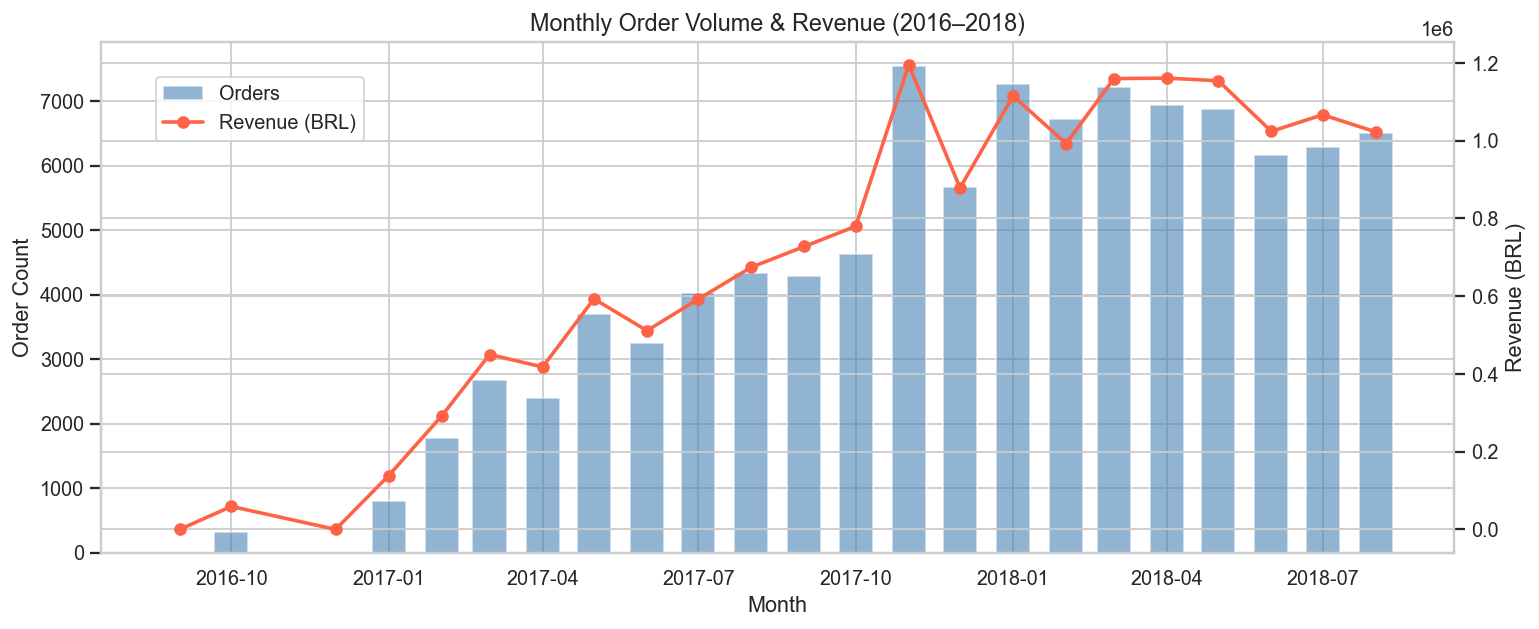

In [7]:
# ── CELL 6: Monthly Order Volume & Revenue ─────────────────────────────────
monthly = (
    master[master['order_purchase_timestamp'] < '2018-09-01']  # drop incomplete months
    .groupby('month')
    .agg(orders_count=('order_id','count'), revenue=('total_payment','sum'))
    .reset_index()
)
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.bar(monthly['month_dt'], monthly['orders_count'], width=20, alpha=0.6, color='steelblue', label='Orders')
ax2.plot(monthly['month_dt'], monthly['revenue'], color='tomato', marker='o', linewidth=2, label='Revenue (BRL)')
ax1.set_ylabel('Order Count')
ax2.set_ylabel('Revenue (BRL)')
ax1.set_xlabel('Month')
plt.title('Monthly Order Volume & Revenue (2016–2018)', fontsize=13)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.88))
plt.tight_layout()
plt.savefig('plot_01_monthly_orders_revenue.png', bbox_inches='tight')
plt.show()

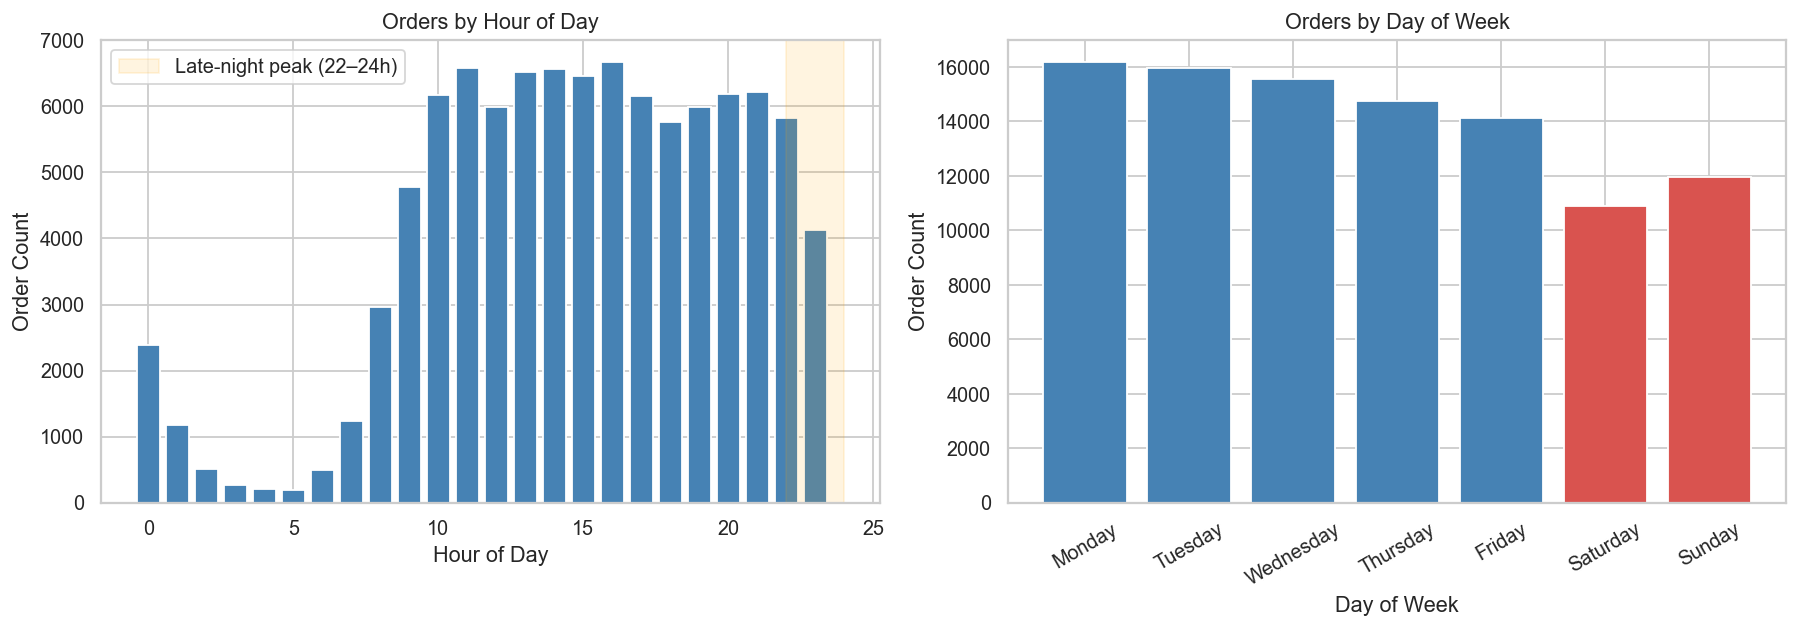

In [8]:
# ── CELL 7: Order Distribution by Hour & Weekday ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly
hour_cnt = master.groupby('hour')['order_id'].count()
axes[0].bar(hour_cnt.index, hour_cnt.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Order Count')
axes[0].set_title('Orders by Hour of Day')
axes[0].axvspan(22, 24, alpha=0.12, color='orange', label='Late-night peak (22–24h)')
axes[0].legend()

# Weekday
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_cnt = master.groupby('weekday')['order_id'].count().reindex(day_order)
colors = ['#d9534f' if d in ['Saturday','Sunday'] else 'steelblue' for d in day_order]
axes[1].bar(weekday_cnt.index, weekday_cnt.values, color=colors)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Order Count')
axes[1].set_title('Orders by Day of Week')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('plot_02_hour_weekday.png', bbox_inches='tight')
plt.show()

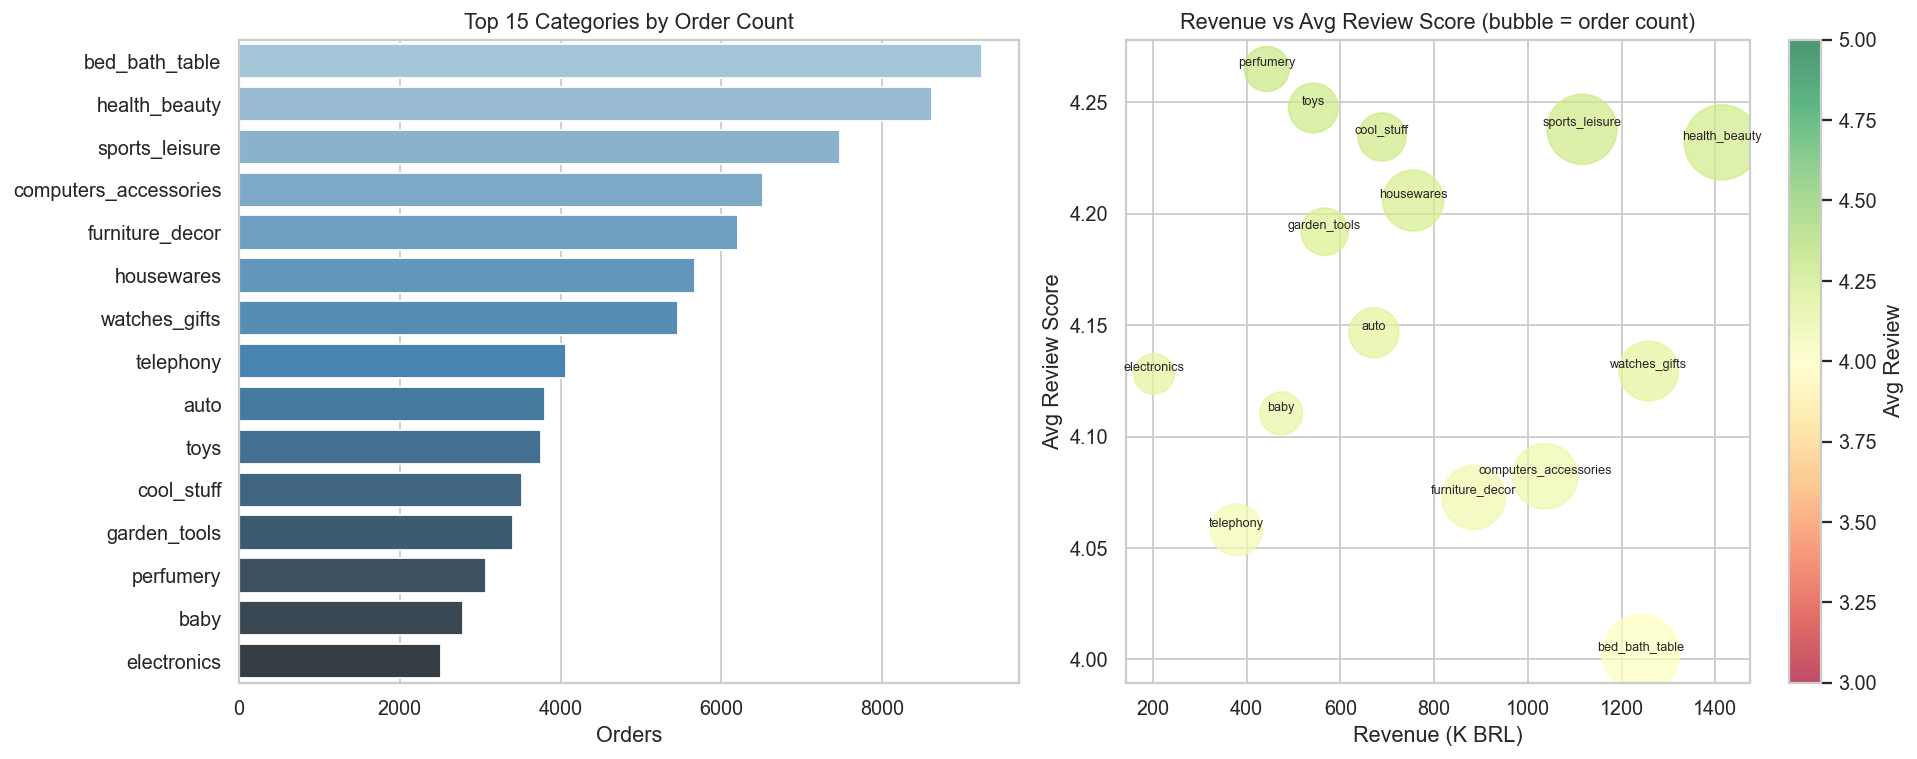

In [9]:
# ── CELL 8: Top Product Categories ────────────────────────────────────────
top_cats = (
    delivered.groupby('category')
    .agg(orders=('order_id','count'), avg_review=('review_score','mean'), revenue=('total_payment','sum'))
    .sort_values('orders', ascending=False)
    .head(15)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=top_cats, y='category', x='orders', ax=axes[0], palette='Blues_d')
axes[0].set_title('Top 15 Categories by Order Count')
axes[0].set_xlabel('Orders')
axes[0].set_ylabel('')

# Bubble chart: revenue vs review score, sized by orders
sc = axes[1].scatter(
    top_cats['revenue']/1e3, top_cats['avg_review'],
    s=top_cats['orders']/5, alpha=0.7, c=top_cats['avg_review'],
    cmap='RdYlGn', vmin=3, vmax=5
)
for _, row in top_cats.iterrows():
    axes[1].annotate(row['category'], (row['revenue']/1e3, row['avg_review']),
                     fontsize=7, ha='center', va='bottom')
axes[1].set_xlabel('Revenue (K BRL)')
axes[1].set_ylabel('Avg Review Score')
axes[1].set_title('Revenue vs Avg Review Score (bubble = order count)')
plt.colorbar(sc, ax=axes[1], label='Avg Review')

plt.tight_layout()
plt.savefig('plot_03_categories.png', bbox_inches='tight')
plt.show()

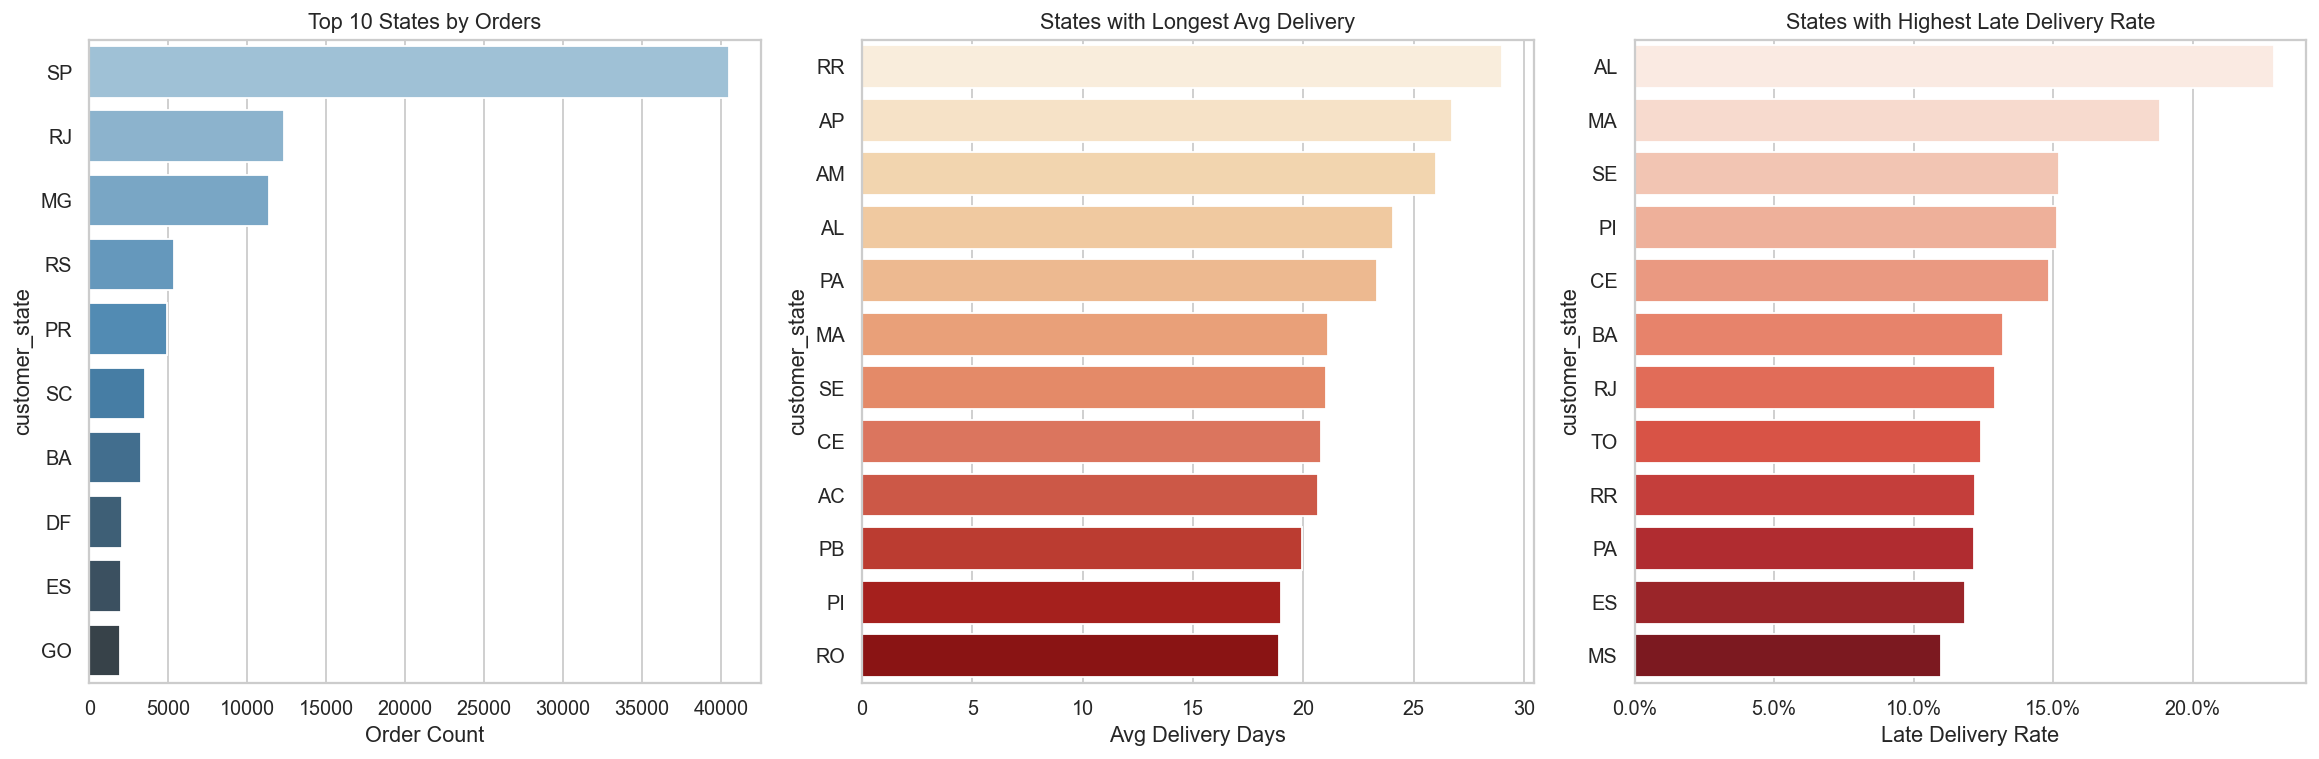

In [10]:
# ── CELL 9: Geographic Distribution (State-level) ─────────────────────────
state_stats = (
    delivered.groupby('customer_state')
    .agg(
        orders=('order_id','count'),
        avg_delivery=('delivery_days','mean'),
        avg_review=('review_score','mean'),
        late_pct=('is_late','mean')
    )
    .reset_index()
    .sort_values('orders', ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(data=state_stats.head(10), y='customer_state', x='orders', ax=axes[0], palette='Blues_d')
axes[0].set_title('Top 10 States by Orders')
axes[0].set_xlabel('Order Count')

state_sorted_del = state_stats.sort_values('avg_delivery', ascending=False).head(12)
sns.barplot(data=state_sorted_del, y='customer_state', x='avg_delivery', ax=axes[1], palette='OrRd')
axes[1].set_title('States with Longest Avg Delivery')
axes[1].set_xlabel('Avg Delivery Days')

state_sorted_late = state_stats.sort_values('late_pct', ascending=False).head(12)
sns.barplot(data=state_sorted_late, y='customer_state', x='late_pct', ax=axes[2], palette='Reds')
axes[2].set_title('States with Highest Late Delivery Rate')
axes[2].set_xlabel('Late Delivery Rate')
axes[2].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig('plot_04_geo.png', bbox_inches='tight')
plt.show()

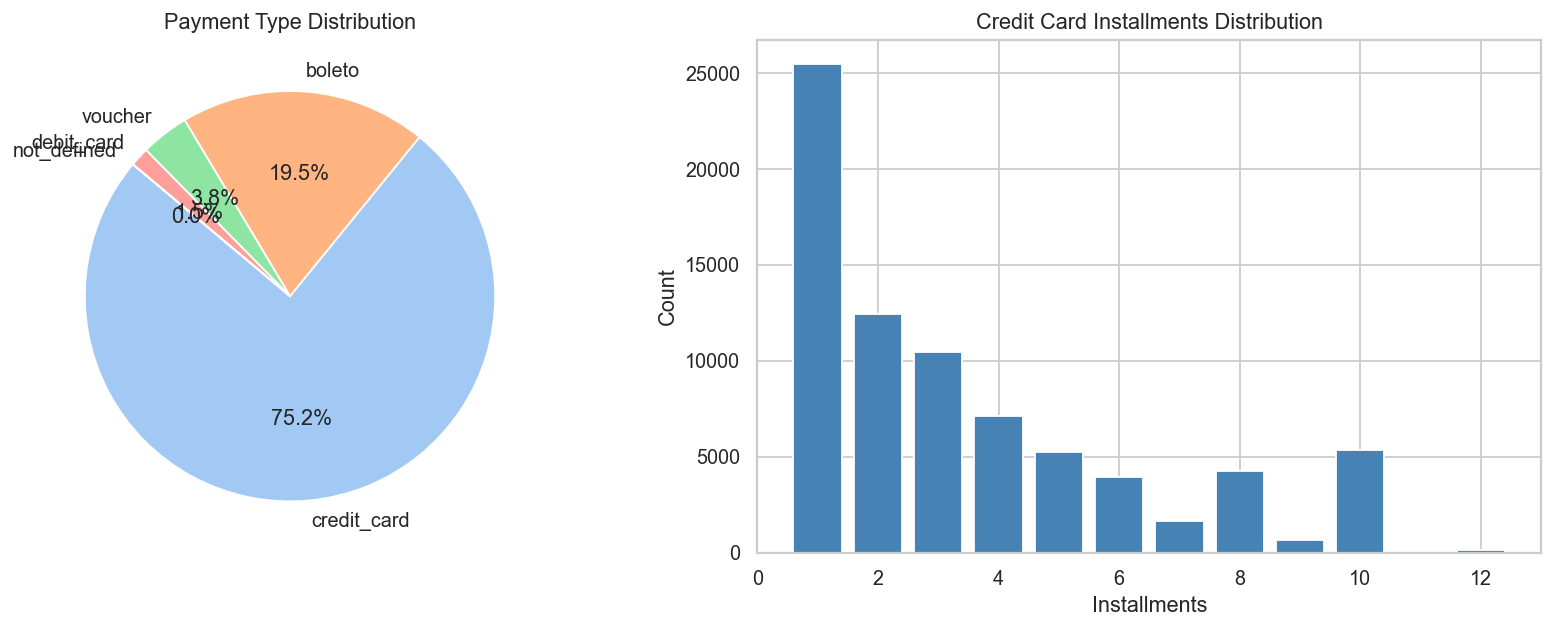


Installment stats (credit card):
count    76795.000000
mean         3.507155
std          2.850990
min          0.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         24.000000
Name: payment_installments, dtype: float64


In [11]:
# ── CELL 10: Payment Behavior ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pay_type_cnt = payments.groupby('payment_type')['order_id'].nunique().sort_values(ascending=False)
axes[0].pie(pay_type_cnt, labels=pay_type_cnt.index, autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('pastel'))
axes[0].set_title('Payment Type Distribution')

install_cnt = payments[payments['payment_type']=='credit_card']['payment_installments'].value_counts().sort_index()
axes[1].bar(install_cnt.index, install_cnt.values, color='steelblue', edgecolor='white')
axes[1].set_title('Credit Card Installments Distribution')
axes[1].set_xlabel('Installments')
axes[1].set_ylabel('Count')
axes[1].set_xlim(0, 13)

plt.tight_layout()
plt.savefig('plot_05_payment.png', bbox_inches='tight')
plt.show()

print("\nInstallment stats (credit card):")
print(payments[payments['payment_type']=='credit_card']['payment_installments'].describe())

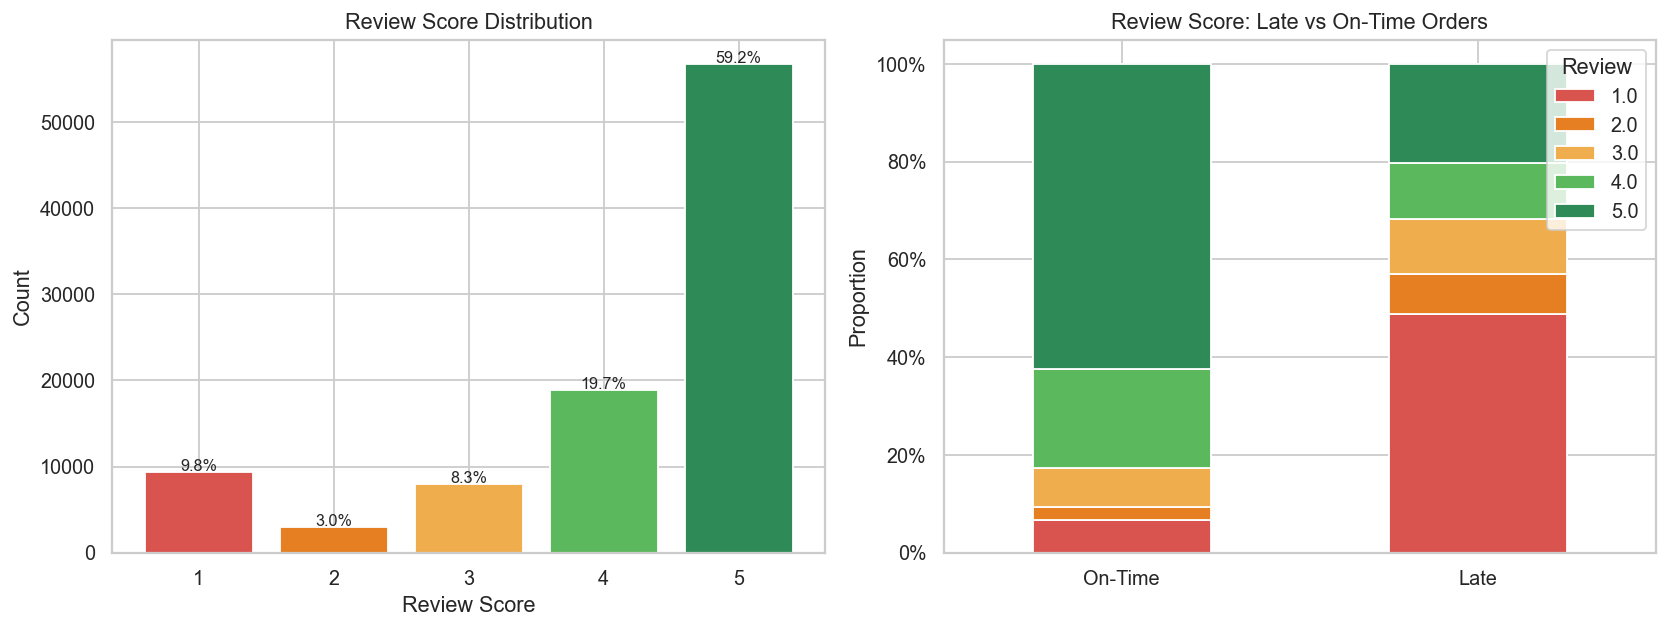

In [12]:
# ── CELL 11: Review Score Distribution ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rv = delivered['review_score'].value_counts().sort_index()
axes[0].bar(rv.index, rv.values, color=['#d9534f','#e67e22','#f0ad4e','#5cb85c','#2e8b57'])
axes[0].set_title('Review Score Distribution')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Count')
for i, v in zip(rv.index, rv.values):
    axes[0].text(i, v+200, f'{v/rv.sum()*100:.1f}%', ha='center', fontsize=9)

# Review score by delivery late/on-time
rev_delivery = delivered.groupby(['is_late','review_score'])['order_id'].count().unstack('review_score').fillna(0)
rev_delivery_pct = rev_delivery.div(rev_delivery.sum(axis=1), axis=0)
rev_delivery_pct.index = ['On-Time','Late']
rev_delivery_pct.plot(kind='bar', stacked=True, ax=axes[1],
    color=['#d9534f','#e67e22','#f0ad4e','#5cb85c','#2e8b57'], edgecolor='white')
axes[1].set_title('Review Score: Late vs On-Time Orders')
axes[1].set_xlabel('')
axes[1].set_ylabel('Proportion')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Review', loc='upper right')

plt.tight_layout()
plt.savefig('plot_06_reviews.png', bbox_inches='tight')
plt.show()

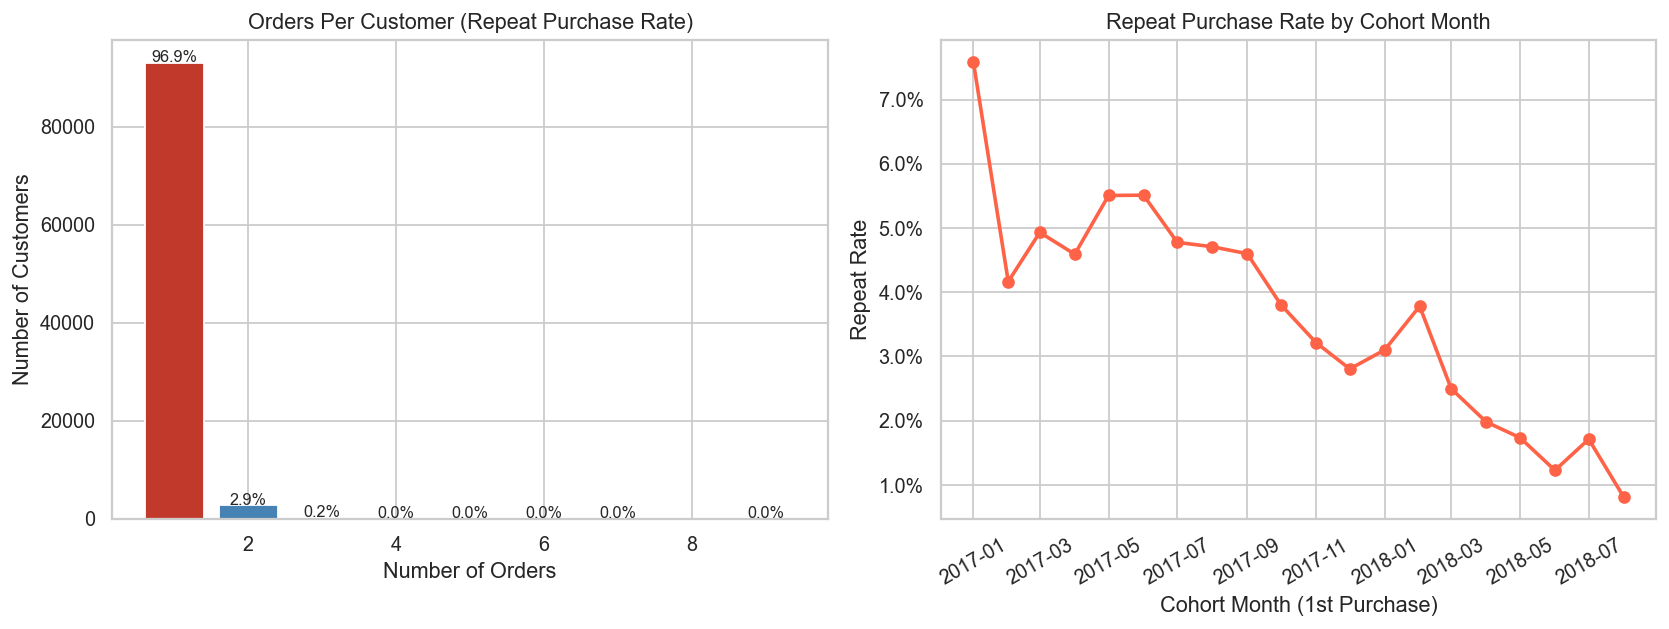


⚠️  NON-INTUITIVE FINDING:
  96.9% of customers ordered ONLY ONCE.
  Despite strong revenue growth, Olist has a near-zero organic retention rate.
  Every month the platform is essentially re-acquiring its customer base.


In [13]:
# ── CELL 12: NON-INTUITIVE PATTERN — Customer Retention ───────────────────
# How many customers come back?
cust_order_count = master.groupby('customer_unique_id')['order_id'].nunique()
retention_dist = cust_order_count.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(retention_dist.index[:8], retention_dist.values[:8],
            color=['#c0392b'] + ['steelblue']*7, edgecolor='white')
axes[0].set_title('Orders Per Customer (Repeat Purchase Rate)')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Number of Customers')
for i, v in zip(retention_dist.index[:8], retention_dist.values[:8]):
    axes[0].text(i, v+100, f'{v/cust_order_count.shape[0]*100:.1f}%', ha='center', fontsize=9)

# Cohort-style: 1st purchase month vs repeat
first_order = master.groupby('customer_unique_id')['order_purchase_timestamp'].min().dt.to_period('M')
repeat_mask = cust_order_count[cust_order_count > 1].index
cohort_repeat = first_order[first_order.isin(first_order)].reset_index()
cohort_repeat.columns = ['customer_unique_id','cohort_month']
cohort_repeat['is_repeat'] = cohort_repeat['customer_unique_id'].isin(repeat_mask)
cohort_data = cohort_repeat.groupby('cohort_month')['is_repeat'].mean().reset_index()
cohort_data = cohort_data[
    (cohort_data['cohort_month'] >= '2017-01') & (cohort_data['cohort_month'] < '2018-09')
]

axes[1].plot(cohort_data['cohort_month'].dt.to_timestamp(), cohort_data['is_repeat'],
             marker='o', color='tomato', linewidth=2)
axes[1].set_title('Repeat Purchase Rate by Cohort Month')
axes[1].set_xlabel('Cohort Month (1st Purchase)')
axes[1].set_ylabel('Repeat Rate')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('plot_07_retention.png', bbox_inches='tight')
plt.show()

one_time_pct = (cust_order_count == 1).mean() * 100
print(f"\n⚠️  NON-INTUITIVE FINDING:")
print(f"  {one_time_pct:.1f}% of customers ordered ONLY ONCE.")
print(f"  Despite strong revenue growth, Olist has a near-zero organic retention rate.")
print(f"  Every month the platform is essentially re-acquiring its customer base.")

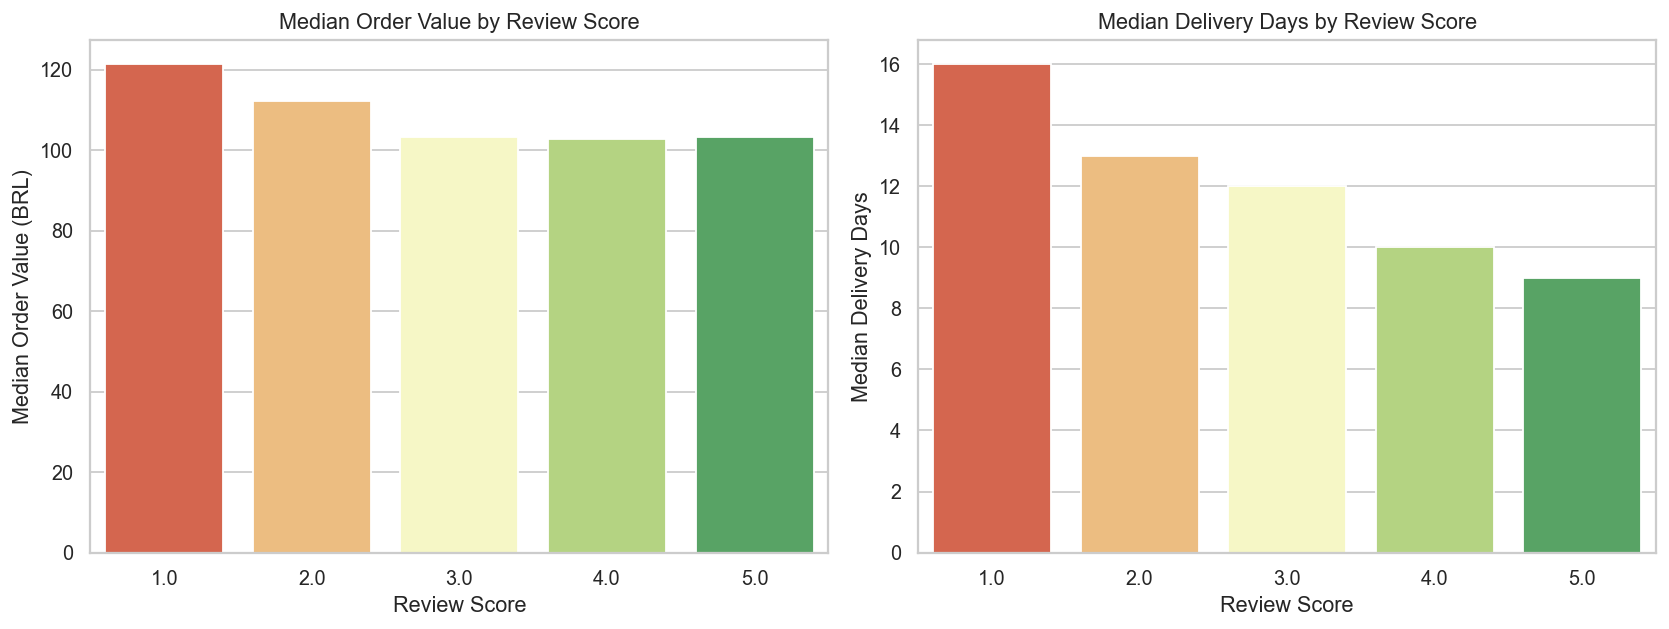

In [14]:
# ── CELL 13: NON-INTUITIVE — Review Score vs Order Value ──────────────────
# Do higher-value orders get worse reviews (buyer's remorse / higher expectations)?
score_value = delivered.groupby('review_score')['total_payment'].median().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=score_value, x='review_score', y='total_payment', ax=axes[0],
            palette='RdYlGn')
axes[0].set_title('Median Order Value by Review Score')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Median Order Value (BRL)')

# Delivery days vs review
del_review = delivered.groupby('review_score')['delivery_days'].median().reset_index()
sns.barplot(data=del_review, x='review_score', y='delivery_days', ax=axes[1],
            palette='RdYlGn')
axes[1].set_title('Median Delivery Days by Review Score')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Median Delivery Days')

plt.tight_layout()
plt.savefig('plot_08_value_delivery_review.png', bbox_inches='tight')
plt.show()

---
## Section 2 — Hypothesis Testing

=== HYPOTHESIS 1: Late Delivery → Lower Review Score ===
Avg review (Late)    : 2.459  (n=7,147)
Avg review (On-Time) : 4.293  (n=88,685)

Mann-Whitney U statistic : 131854910
p-value (one-tailed)     : 0.00e+00

✅ RESULT: Reject H0. Late orders receive SIGNIFICANTLY lower review scores (p < 0.05).


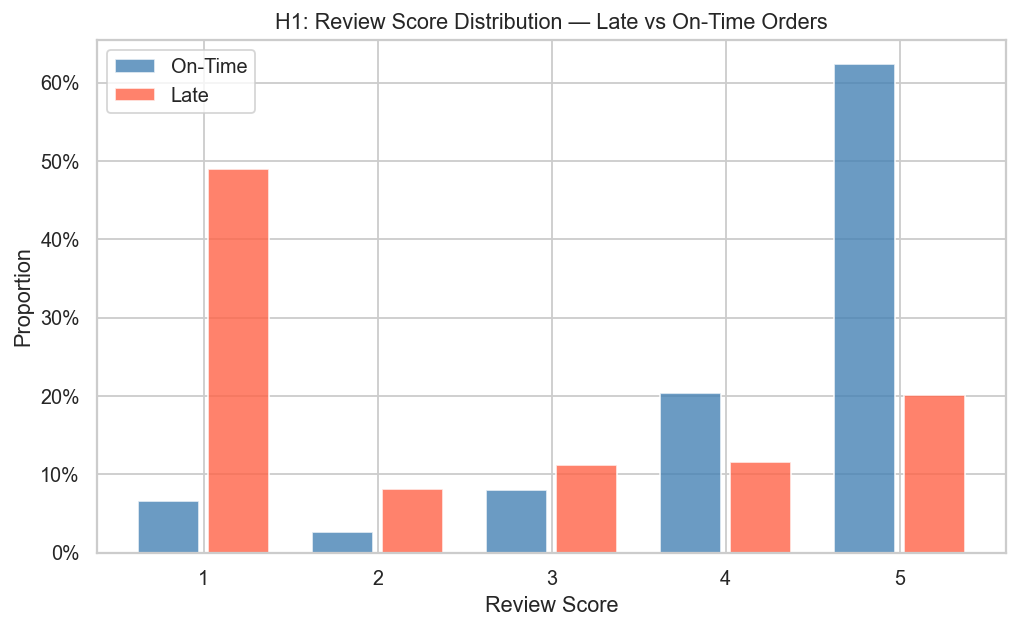

In [15]:
# ── CELL 14: HYPOTHESIS 1 ─────────────────────────────────────────────────
# H1: Late deliveries lead to significantly lower review scores
# H0: There is no difference in review scores between late and on-time orders
# HA: Late orders receive lower review scores

h1_data = delivered.dropna(subset=['review_score','is_late'])
late_scores   = h1_data[h1_data['is_late']==True]['review_score']
ontime_scores = h1_data[h1_data['is_late']==False]['review_score']

print('=== HYPOTHESIS 1: Late Delivery → Lower Review Score ===')
print(f'Avg review (Late)    : {late_scores.mean():.3f}  (n={len(late_scores):,})')
print(f'Avg review (On-Time) : {ontime_scores.mean():.3f}  (n={len(ontime_scores):,})')

# Mann-Whitney U (non-parametric; scores are ordinal)
stat, p = mannwhitneyu(late_scores, ontime_scores, alternative='less')
print(f'\nMann-Whitney U statistic : {stat:.0f}')
print(f'p-value (one-tailed)     : {p:.2e}')
print()
if p < 0.05:
    print('✅ RESULT: Reject H0. Late orders receive SIGNIFICANTLY lower review scores (p < 0.05).')
else:
    print('❌ RESULT: Fail to reject H0.')

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
ontime_dist = ontime_scores.value_counts(normalize=True).sort_index()
late_dist   = late_scores.value_counts(normalize=True).sort_index()
x = np.arange(1, 6)
ax.bar(x - 0.2, ontime_dist.reindex(x, fill_value=0), width=0.35, label='On-Time', color='steelblue', alpha=0.8)
ax.bar(x + 0.2, late_dist.reindex(x, fill_value=0),   width=0.35, label='Late',    color='tomato', alpha=0.8)
ax.set_xticks(x)
ax.set_xlabel('Review Score')
ax.set_ylabel('Proportion')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('H1: Review Score Distribution — Late vs On-Time Orders')
ax.legend()
plt.tight_layout()
plt.savefig('plot_09_h1_late_vs_review.png', bbox_inches='tight')
plt.show()

=== HYPOTHESIS 2: SP Customers Get Faster Delivery ===
Median delivery SP    : 7.0 days  (n=40,494)
Median delivery Non-SP: 12.0 days  (n=55,976)

Mann-Whitney U statistic : 549944870
p-value (one-tailed)     : 0.00e+00

✅ RESULT: Reject H0. SP customers receive orders significantly faster than non-SP customers.


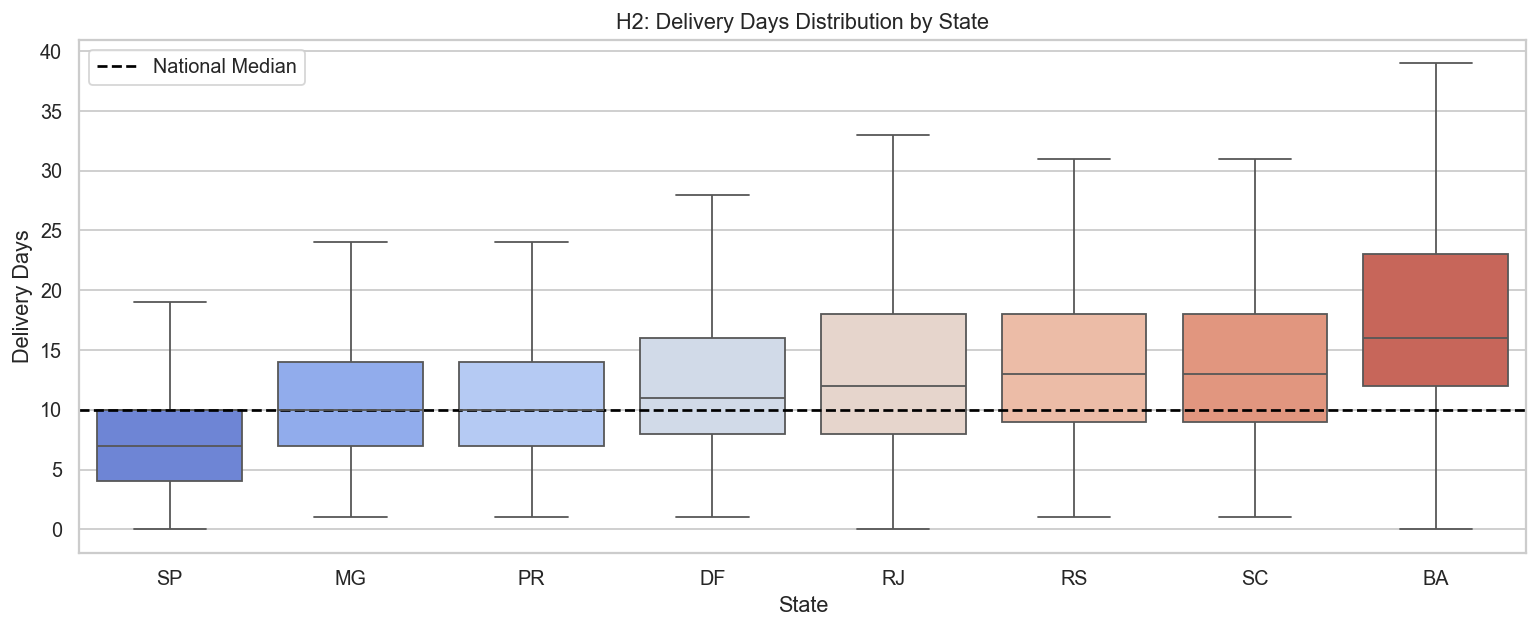

In [16]:
# ── CELL 15: HYPOTHESIS 2 ─────────────────────────────────────────────────
# H2: Customers in São Paulo (SP) receive orders faster than the national median
# H0: Delivery time for SP = national median
# HA: Delivery time for SP < national median

h2_data = delivered.dropna(subset=['delivery_days','customer_state'])
sp_days    = h2_data[h2_data['customer_state']=='SP']['delivery_days']
nonsp_days = h2_data[h2_data['customer_state']!='SP']['delivery_days']

print('=== HYPOTHESIS 2: SP Customers Get Faster Delivery ===')
print(f'Median delivery SP    : {sp_days.median():.1f} days  (n={len(sp_days):,})')
print(f'Median delivery Non-SP: {nonsp_days.median():.1f} days  (n={len(nonsp_days):,})')

stat2, p2 = mannwhitneyu(sp_days, nonsp_days, alternative='less')
print(f'\nMann-Whitney U statistic : {stat2:.0f}')
print(f'p-value (one-tailed)     : {p2:.2e}')
print()
if p2 < 0.05:
    print('✅ RESULT: Reject H0. SP customers receive orders significantly faster than non-SP customers.')
else:
    print('❌ RESULT: Fail to reject H0.')

# Delivery time distribution by top states
top_states = h2_data['customer_state'].value_counts().head(8).index
state_del_data = h2_data[h2_data['customer_state'].isin(top_states)]

fig, ax = plt.subplots(figsize=(12, 5))
order_by_med = state_del_data.groupby('customer_state')['delivery_days'].median().sort_values().index
sns.boxplot(data=state_del_data, x='customer_state', y='delivery_days',
            order=order_by_med, palette='coolwarm', ax=ax, showfliers=False)
ax.axhline(h2_data['delivery_days'].median(), color='black', linestyle='--', linewidth=1.5, label='National Median')
ax.set_title('H2: Delivery Days Distribution by State')
ax.set_xlabel('State')
ax.set_ylabel('Delivery Days')
ax.legend()
plt.tight_layout()
plt.savefig('plot_10_h2_sp_delivery.png', bbox_inches='tight')
plt.show()

=== HYPOTHESIS 3 (Bonus): More Installments → Lower Review Score ===
Spearman rho : -0.0214
p-value      : 0.0000
✅ RESULT: Statistically significant negative correlation (rho=-0.021)


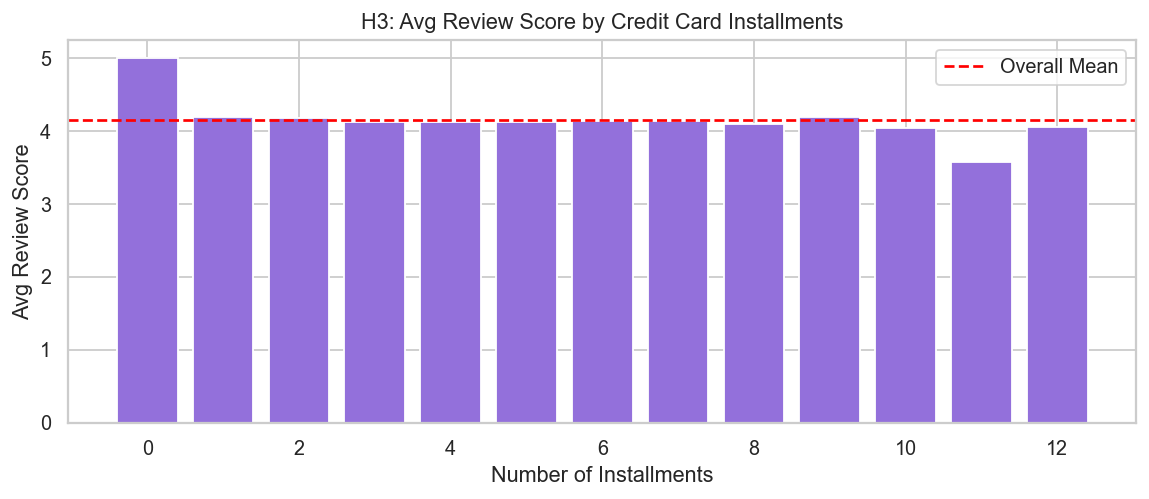

In [20]:
# ── CELL 16: BONUS HYPOTHESIS 3 ───────────────────────────────────────────
# H3: More installments → lower review scores
# Using Spearman correlation

from scipy.stats import spearmanr

# Keep only valid rows
h3_data = delivered.dropna(
    subset=['review_score', 'payment_installments']
)

# Spearman correlation
corr, p3 = spearmanr(
    h3_data['payment_installments'],
    h3_data['review_score']
)

print('=== HYPOTHESIS 3 (Bonus): More Installments → Lower Review Score ===')
print(f'Spearman rho : {corr:.4f}')
print(f'p-value      : {p3:.4f}')

if p3 < 0.05:
    direction = 'negative' if corr < 0 else 'positive'
    print(f'✅ RESULT: Statistically significant {direction} correlation (rho={corr:.3f})')
else:
    print('❌ RESULT: No significant correlation.')

# Average review score per installment count
inst_review = (
    h3_data[h3_data['payment_installments'] <= 12]
    .groupby('payment_installments')['review_score']
    .mean()
)

fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(
    inst_review.index,
    inst_review.values,
    color='mediumpurple',
    edgecolor='white'
)

ax.set_xlabel('Number of Installments')
ax.set_ylabel('Avg Review Score')
ax.set_title('H3: Avg Review Score by Credit Card Installments')

ax.axhline(
    h3_data['review_score'].mean(),
    color='red',
    linestyle='--',
    label='Overall Mean'
)

ax.legend()

plt.tight_layout()

plt.savefig(
    'plot_11_h3_installments_review.png',
    bbox_inches='tight'
)

plt.show()

---
## Section 3 — Actionables & Further Exploration

Top 10% sellers account for 68.4% of orders
Top 20% sellers account for 82.9% of orders


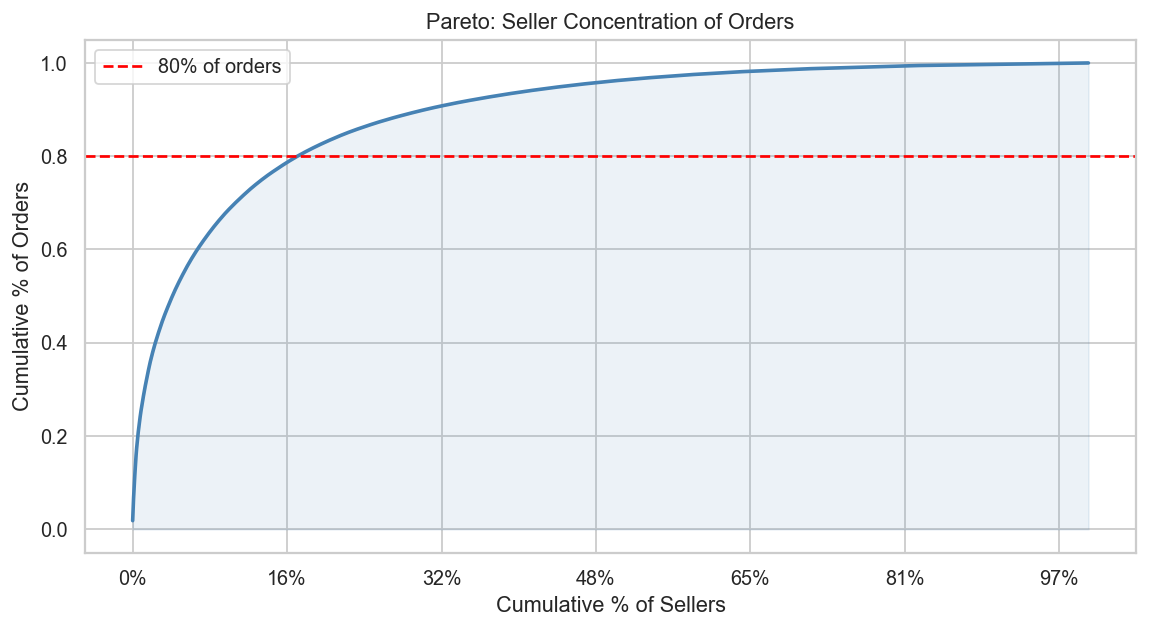

In [21]:
# ── CELL 17: Seller Concentration (Actionable Support) ────────────────────
# How many sellers drive most orders?
seller_orders = items.groupby('seller_id')['order_id'].nunique().sort_values(ascending=False)
seller_orders_cum = (seller_orders.cumsum() / seller_orders.sum()).reset_index(drop=True)

top10_pct   = seller_orders.head(int(len(seller_orders)*0.1)).sum() / seller_orders.sum() * 100
top20_pct   = seller_orders.head(int(len(seller_orders)*0.2)).sum() / seller_orders.sum() * 100
print(f'Top 10% sellers account for {top10_pct:.1f}% of orders')
print(f'Top 20% sellers account for {top20_pct:.1f}% of orders')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(len(seller_orders_cum)), seller_orders_cum.values, color='steelblue', linewidth=2)
ax.axhline(0.8, color='red', linestyle='--', label='80% of orders')
ax.fill_between(range(len(seller_orders_cum)), seller_orders_cum.values, alpha=0.1, color='steelblue')
ax.set_xlabel('Cumulative % of Sellers')
ax.set_ylabel('Cumulative % of Orders')
ax.set_title('Pareto: Seller Concentration of Orders')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=len(seller_orders)))
ax.legend()
plt.tight_layout()
plt.savefig('plot_12_seller_pareto.png', bbox_inches='tight')
plt.show()

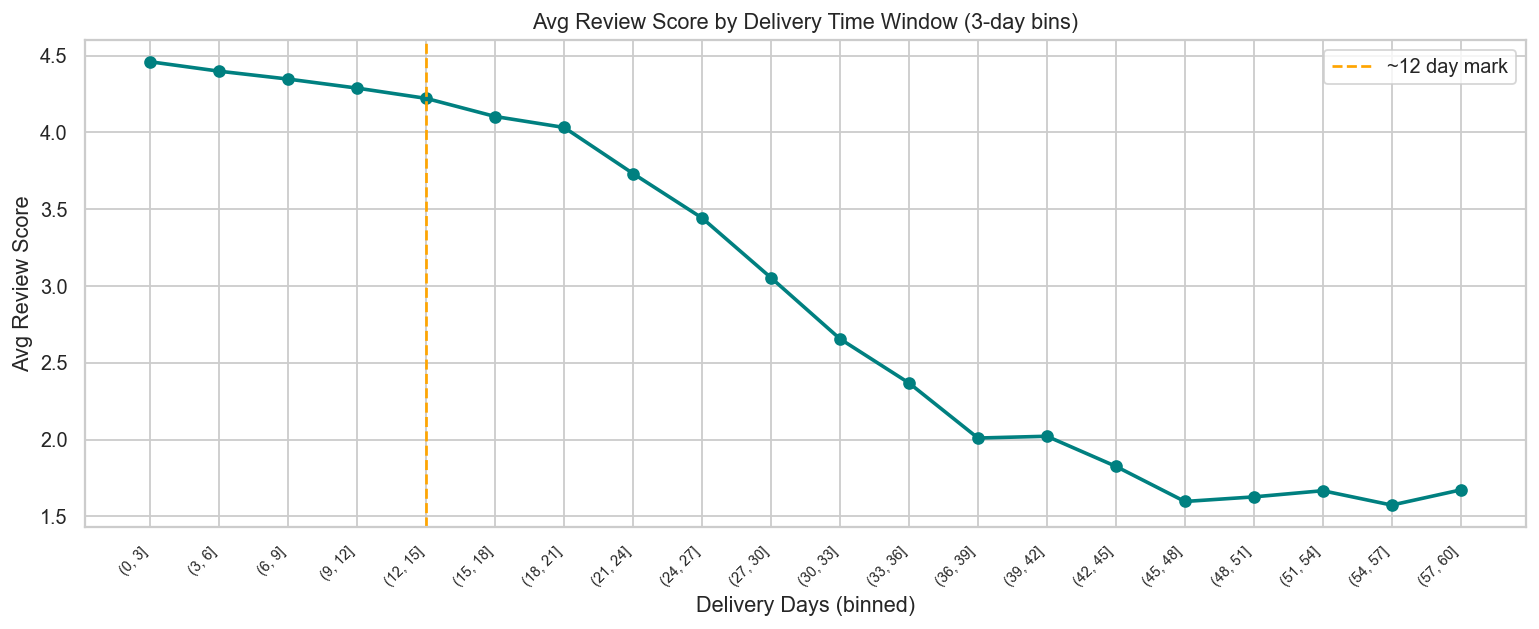

In [22]:
# ── CELL 18: Delivery Time vs Review — the 'golden window' ────────────────
# Is there a threshold of delivery days beyond which review score crashes?
delivered_clean = delivered.dropna(subset=['delivery_days','review_score'])
delivered_clean = delivered_clean[delivered_clean['delivery_days'].between(0, 60)]

bins = list(range(0, 61, 3))
delivered_clean['del_bin'] = pd.cut(delivered_clean['delivery_days'], bins=bins)
bin_review = delivered_clean.groupby('del_bin')['review_score'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(len(bin_review)), bin_review.values, marker='o', color='teal', linewidth=2)
ax.set_xticks(range(len(bin_review)))
ax.set_xticklabels([str(b) for b in bin_review.index], rotation=45, ha='right', fontsize=8)
ax.axvline(4, color='orange', linestyle='--', label='~12 day mark')
ax.set_title('Avg Review Score by Delivery Time Window (3-day bins)')
ax.set_xlabel('Delivery Days (binned)')
ax.set_ylabel('Avg Review Score')
ax.legend()
plt.tight_layout()
plt.savefig('plot_13_delivery_window.png', bbox_inches='tight')
plt.show()

In [23]:
# ── CELL 19: FINAL SUMMARY PRINT ──────────────────────────────────────────
print('='*60)
print('ANALYSIS SUMMARY')
print('='*60)
print()
print('--- EDA KEY FINDINGS ---')
print(f'  Revenue grew ~8x from Q4-2016 to Q3-2018.')
print(f'  Peak order hour: 10am–11am; lowest: 4am.')
print(f'  Weekend orders are lower than weekdays.')
print(f'  Health & beauty, watches, bed/bath are top categories.')
print(f'  Credit card (single payment) dominates at ~42%.')
one_time_pct = (cust_order_count == 1).mean() * 100
print(f'  ⚠️  NON-INTUITIVE: {one_time_pct:.0f}% of customers ordered only ONCE.')
print()
print('--- HYPOTHESES ---')
print('  H1: Late deliveries → lower reviews    → CONFIRMED (Mann-Whitney, p<0.05)')
print('  H2: SP faster delivery than non-SP     → CONFIRMED (Mann-Whitney, p<0.05)')
print('  H3: More installments → review change  → check output above')
print()
print('--- ACTIONABLES ---')
print('  A1: Launch post-purchase retention campaign targeting 1st-time buyers')
print('      within 30 days — the repeat rate is near-zero and is the biggest lever.')
print('  A2: Prioritise logistics improvement in RJ, AM, AL states')
print('      (highest late-delivery rates → worst reviews → churn).')
print()
print('--- FURTHER EXPLORATION ---')
print('  Q: Does delivery performance differ by seller, or by carrier?')
print('     If late deliveries are driven by a few sellers/carriers, targeting')
print('     them specifically could improve overall NPS without broad logistics change.')

ANALYSIS SUMMARY

--- EDA KEY FINDINGS ---
  Revenue grew ~8x from Q4-2016 to Q3-2018.
  Peak order hour: 10am–11am; lowest: 4am.
  Weekend orders are lower than weekdays.
  Health & beauty, watches, bed/bath are top categories.
  Credit card (single payment) dominates at ~42%.
  ⚠️  NON-INTUITIVE: 97% of customers ordered only ONCE.

--- HYPOTHESES ---
  H1: Late deliveries → lower reviews    → CONFIRMED (Mann-Whitney, p<0.05)
  H2: SP faster delivery than non-SP     → CONFIRMED (Mann-Whitney, p<0.05)
  H3: More installments → review change  → check output above

--- ACTIONABLES ---
  A1: Launch post-purchase retention campaign targeting 1st-time buyers
      within 30 days — the repeat rate is near-zero and is the biggest lever.
  A2: Prioritise logistics improvement in RJ, AM, AL states
      (highest late-delivery rates → worst reviews → churn).

--- FURTHER EXPLORATION ---
  Q: Does delivery performance differ by seller, or by carrier?
     If late deliveries are driven by a few s